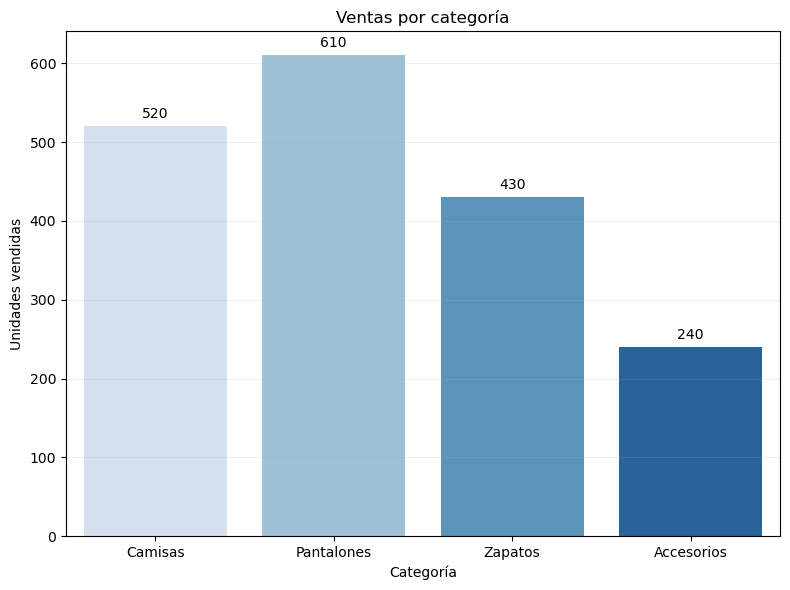

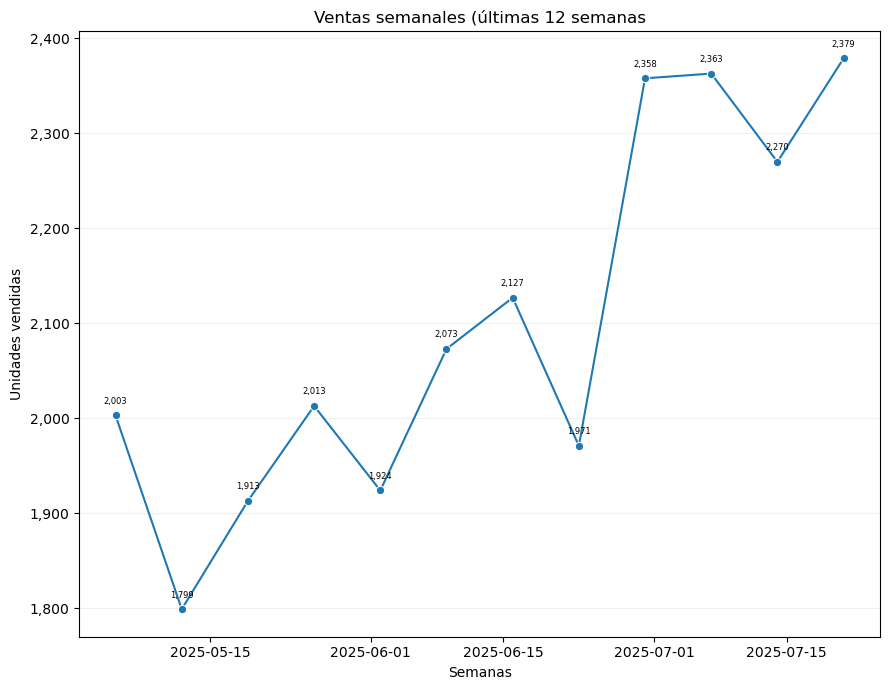

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

#datos por mes
categorias = ['Camisas','Pantalones','Zapatos','Accesorios']
ventas_cat = [520,610,430,240]
df_cat = pd.DataFrame({'Categoria': categorias, 'Ventas': ventas_cat})

#datos por semana
np.random.seed(7)
fechas = pd.date_range('2025-05-01', periods=12, freq='W-MON')
base = np.linspace(1800,2400,12)
ruido = np.random.normal(0,120,12)
ventas_sem = np.round(base + ruido).astype(int)
df_sem = pd.DataFrame({'Semana': fechas, 'Ventas': ventas_sem})
#comparar el desempeño por categoría
#--------------------------------------- grafico de barra
plt.figure(figsize=(8,6))
#sns.barplot(data=df_cat, x='Categoria', y='Ventas', palette='blue')
sns.barplot(x="Categoria", y="Ventas", data=df_cat, hue="Categoria", palette="Blues", legend=False)
plt.title("Ventas por categoría")
plt.xlabel('Categoría')
plt.ylabel('Unidades vendidas')
#poner los valores encima de cada barra

for i, v in enumerate(df_cat['Ventas']):
    plt.text(i, v+10, str(v), ha='center', fontsize=10 )

plt.tight_layout() #ordena elgráfico, se va adaptando, ayuda a que no se distorsione
plt.grid(True, axis='y', alpha=0.2)
plt.show()


#--------------------------------------- grafico de líneas

plt.figure(figsize=(9,7))
sns.lineplot(data=df_sem, x='Semana', y='Ventas', marker='o')

plt.title('Ventas semanales (últimas 12 semanas')
plt.xlabel('Semanas')
plt.ylabel('Unidades vendidas')

# ✅ Formateador para separar miles con coma
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))

# ✅ Añadir etiquetas de valor encima de cada punto
for x, y in zip(df_sem['Semana'], df_sem['Ventas']):
    plt.text(x, y+10, f"{y:,}", ha='center', va='bottom', fontsize=6)

plt.grid(True, axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

